# Particle in a Box and Molecular Conjugation

In this lab, we will build, test, and compare mathematical models that describe electrons confined within molecules. Starting from physical principles, we will construct a particle-in-a-box model, solve it numerically, and compare its predictions to full quantum-chemical calculations on real molecules. Along the way, you will practice curve fitting, numerical optimization, and computational chemistry — skills that are central to modern physical chemistry research.

---

**Chemistry Learning Objectives:**
- C4.1: Solve the Schrödinger equation for the particle in a box (PIB) using numerical methods.
- C4.2: Connect features of PIB wavefunctions to their energies.
- C4.3: Use the Self-Consistent Field/Hartree-Fock (SCF) method to predict chemical phenomena.
- C4.4: Compare predictions of PIB and SCF models for conjugated polyenes.

**Programming Learning Objectives:**
- P4.1: Perform numerical optimization routines with `scipy`.
- P4.2: Fit nonlinear curves to data using numerical optimization.
- P4.3: Perform quantum chemical calculations with the `psi4` software package.

---

**Table of Contents**
- [Warmup — Curve Fitting](#warmup)
- [Part 1 — Solving the Schrödinger Equation](#part1)
- [Part 2 — Energy Levels of the Particle in a Box](#part2)
- [Part 3 — Computational Chemistry](#part3)
- [Part 4 — Comparing Models](#part4)
- [Reflection](#reflection)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, minimize
import psi4
import fortecubeview
import shutil

from pib_helper import (compute_energy, create_psi4_molecule,
                        load_psi4_molecule, calculate_r_squared)

<a id="warmup"></a>

## Warmup — Curve Fitting and Physical Models

The statistician George Box famously observed:

> *"All models are wrong, but some are useful."*

Throughout science, we use **models** — simplified mathematical descriptions — to make sense of complex systems. A model does not need to be perfect to be valuable; it needs to capture the features we care about. In this lab, we will build several models of increasing sophistication and evaluate how well each one works.

A foundational skill for working with models is **curve fitting**: given experimental (or computational) data, finding a mathematical function that describes it. Let's practice this now.

### Coding Activity (Warmup)
`15 points`

- P4.2: Fit nonlinear curves to data.

You have gotten some practice performing linear regression on data. You aren't limited to this - you can actually fit arbitrary functional forms. We'll use `scipy.optimize.curve_fit` for this.


### W.A

Let's take a look at this mysterious data. By now, you should be able to load data using `pandas` and plot it using `matplotlib`.

**Your task:**
1. Load the data from `data/mystery_curve.csv` 
2. Make a scatter plot with axis labels and a title.


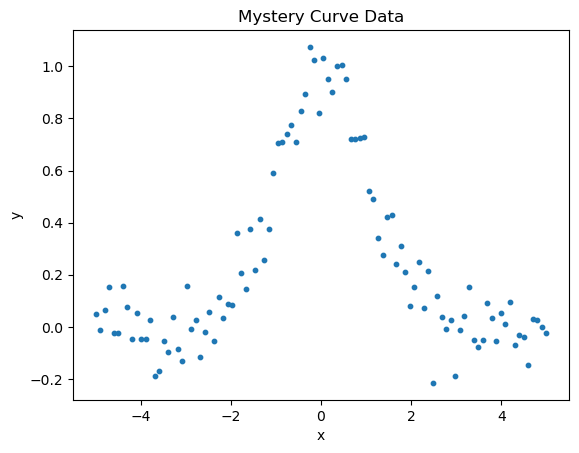

In [2]:
# Subgoal: Load and inspect the data
mystery_curve = pd.read_csv('data/mystery_curve.csv')
plt.scatter(mystery_curve['x'], mystery_curve['y'], s=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Mystery Curve Data')
plt.show()

### W.B - Learning from a worked example

Now we will practice fitting functions of our creation to this data! We'll use [`scipy.optimize.curve_fit`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html) — read the linked documentation if you want more detail on how it works.

**Your task:**
1. Read the code in the two cells below carefully.
2. Add a comment to each line explaining what it does and why.
3. Run both cells and observe the output.

In [3]:
from scipy.optimize import curve_fit

def abs_x(x, m, b):
    return m * np.abs(x) + b

params, covariance = curve_fit(
                    abs_x,                    # YOUR COMMENT HERE
                    mystery_curve['x'],       # YOUR COMMENT HERE
                    mystery_curve['y'],       # YOUR COMMENT HERE
                    p0=[1, 0])                # YOUR COMMENT HERE
print("Params:", params)

Params: [-0.19892318  0.74010271]


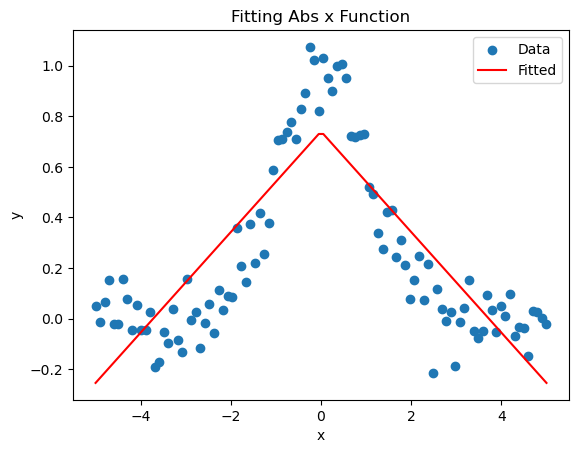

In [4]:
plt.scatter(mystery_curve['x'], mystery_curve['y'], label='Data')  # YOUR COMMENT HERE

x_fit = np.linspace(-5, 5, 100)               # YOUR COMMENT HERE
m = params[0]                                  # YOUR COMMENT HERE
b = params[1]                                  # YOUR COMMENT HERE
y_fit = abs_x(x_fit, m, b)                    # YOUR COMMENT HERE
plt.plot(x_fit, y_fit, label='Fitted', color='red')  # YOUR COMMENT HERE

plt.xlabel('x')                                # YOUR COMMENT HERE
plt.ylabel('y')                                # YOUR COMMENT HERE
plt.title('Fitting Abs x Function')            # YOUR COMMENT HERE
plt.legend()                                   # YOUR COMMENT HERE
plt.show()

### W.C - Fitting your own function

Now it's your turn! Define a different function and fit it to the same data.

**Your task:**
1. Define a new candidate function (e.g., Gaussian, exponential decay, quadratic — anything you think might match the shape of the data).
2. Use `curve_fit` to find the best parameters.
3. Plot the data and your fitted curve together.
4. Does your function fit the data better or worse than the absolute-value function above?

In [ ]:
# Subgoal: Define your candidate function
# # YOUR CODE HERE

# Subgoal: Fit your function to the data
# params, covariance = curve_fit(...)

# y_fit = your_function(x, *params) # * is the unpacking operator if used on a list

# Subgoal: Plot the data and your fitted curve
# plt.scatter(...)
# plt.plot(...)
# plt.xlabel(...)
# plt.ylabel(...)
# plt.title(...)
# plt.legend()
# plt.show()

### Question (Warmup)
`5 points`

a) Which of your candidate functions best fit the data? How did you decide?

b) Propose an example of a situation where you could use this technique in a real scientific application.

c) In the example you gave, how would the curve be useful to us? How about the parameters?

---

*Your answer here (`double click me!`):*

<br></br>

<a id="part1"></a>
## Part 1 - Numerically Solving the Schrodinger Equation

**The Schrodinger Equation and Energy**

Suppose we wanted to calculate the energy of an electron. What would we do?

Well, we can use the *Time-Independent Schrodinger Equation*, which tells us that the total energy of our wavefunction is the sum of the potential and kinetic energies.
$$
\hat{H} \psi{}(x) = \hat{T}\psi{}(x)  + \hat{V}(x)\psi(x)
$$
Where $\psi{}(x)$ is the wavefunction, $\hat{H}$ is the Hamiltonian (i.e. the Energy operator), $\hat{T}$ is the kinetic energy operator, and $\hat{V}(x)$ is the potential energy (as a function of x).


**Eigenvalues and Eigenfunctions**

For a wavefunction to have a clearly defined energy, it must satisfy: 
$$ \hat{H}\psi = E \psi $$
Where $E$ is constant. 

In these special cases, we say that $\psi$ is an _eigenfunction_ of the energy operator $\hat{H}$, and the observed energy $E$ is an _eigenvalue_. Okay, great. If you want the wavefunction of a system, just find the eigenvalues of the Schrodinger Equation. And in fact, we can do that for the particle-in-a-box, as you may have learned in lecture.

**Numerical Solutions**

Most real chemical systems, however, do *not* admit closed-form solutions. For real molecules, potentials are complicated, electrons interact, and analytic expressions are rarely obtainable. In practice, chemists often rely on numerical methods to discover physically meaningful solutions rather than writing them down algebraically.

To see how this works in a controlled setting, we will approach the particle-in-a-box problem *numerically*, instead of *analytically* (like you may have in lecture). 

Instead of solving for the eigenfunction directly, we define a quantity that measures how "energetically costly" a candidate wavefunction is and minimize it. One useful choice is the average value (expectation value) of the energy, which is well-defined even for non-eigenfunctions:
$$
\braket{E} = \frac{\int_0^L \psi^*(x)\hat{H}\psi(x) dx}{\int_0^L |\psi(x)|^2 dx}.
$$
Where $\hat{H} = \hat{T} =  -\frac{\hbar{}}{2m}\frac{d^2}{dx^2}$ for the particle-in-a-box system.

The numerator measures energy and the denominator ensures normalization. Minimizing E is equivalent to asking: Among all functions that satisfy the boundary conditions, which one has the lowest kinetic energy?

---

## Coding Activity 1
`25 points`

- C4.1: Solve the Schrödinger equation for an electron using numerical methods.
- P4.1: Perform numerical optimization routines with `scipy`.



### Part A — Calculate Energies For Trial Wavefunctions

Write at least three different trial functions for $\psi(x)$ that satisfy the boundary conditions $\psi(0) = \psi(L) = 0$. Some ideas:
- A polynomial like $x(L - x)$
- A Gaussian multiplied by $x(L - x)$
- A sine wave that satisfies the boundary conditions like $sin(\frac{\pi{}}{L}x)$

Each function should take an array `x` as input and return an array of the same shape.

For each trial function:
1. Plot it using the `plot_trial` function defined below.
2. Compute its energy using `compute_energy` from the helper.
3. Record which function has the lowest energy.

In [5]:
# --- Given: plotting utility ---
# This function plots a trial wavefunction on a box of length L.
# You can read through this to see how it works, but you don't need to modify it.
def plot_wavefunction(x, y, label=None):
    """Plot a trial wavefunction and shade the box region."""
    if not abs(y[0]) < 0.0001 or not abs(y[-1]) < 0.0001:
        raise ValueError("Trial wavefunction must satisfy boundary conditions (psi(0) = psi(L) = 0).")
    # evaluate energy
    E = compute_energy(y, x)
    plt.plot(x, y, label=label + f" (E={E:.3f})")
    plt.axhline(0, color='grey', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.4)
    plt.axvline(x[-1], color='black', linewidth=1, linestyle='--', alpha=0.4)
    plt.xlabel('x')
    plt.ylabel(r'$\psi(x)$')
    plt.title('Wavefunctions & Energies')
    plt.legend()

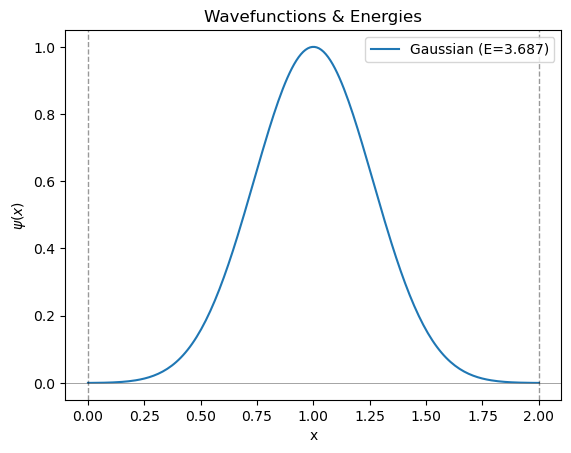

In [9]:
L = 2.0
x = np.linspace(0, L, 200)

# Example: Gaussian bump (provided)
def gaussian(x):
    center, width = L/2, L/5 
    return np.exp(-((x - center)**2) / width**2) * (x * (L - x))  # Ensure it goes to zero at boundaries


plot_wavefunction(x, gaussian(x), label='Gaussian')

In [ ]:
# YOUR CODE HERE — define another trial function (e.g. a sine wave, sin(pi x / L)) and plot it

In [ ]:
# YOUR CODE HERE - define another trial function and plot it

#### Part B — Optimizing wavefunctions

You've constructed several guess wavefunctions and evaluated their energies. Imagine you wanted to find the wavefunction which had the lowest energy. How would you approach this?

Rather than try different functional forms by hand, we can just use our energy functional and our guess wavefunctions to **optimize** the wavefunction! 

We will use a numerical optimization algorithm which will iteratively refine our guess to minimize the energy until it cannot make the energy any lower. 

**Your task:**

- Use `scipy.optimize.minimize` to find the wavefunction that minimizes the energy.
- Plot the wavefunction before and after minimization using plot_wavefunction().
- **Leave comments explaining the worked example.**

(Hint: It will help you to write down the names of the functions you created as a reference for this part)

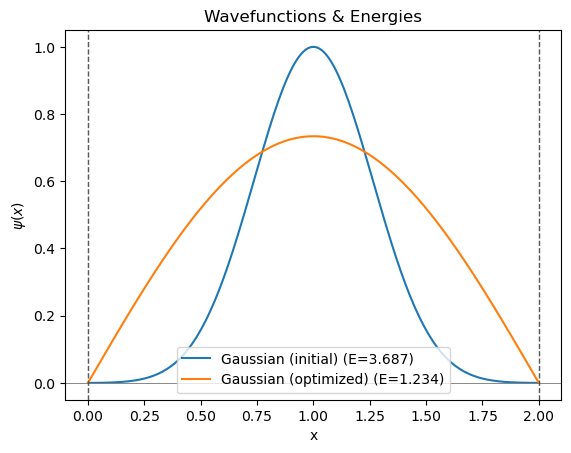

In [12]:
# Subgoal: Minimize energy for the Gaussian trial function

y_guess = gaussian(x)                                                       #YOUR COMMENT HERE
result_gauss = minimize(compute_energy, y_guess, args=(x,), method='CG')    #YOUR COMMENT HERE

#the variable name 'result_gauss.x' is confusing here. it is really the y values in our case, 
# but this is the convention minimize uses.
phi_gauss_opt = result_gauss.x                                              #YOUR COMMENT HERE
plot_wavefunction(x, y_guess, label='Gaussian (initial)')                   #YOUR COMMENT HERE
plot_wavefunction(x, phi_gauss_opt, label='Gaussian (optimized)')           #YOUR COMMENT HERE
plt.show()

In [ ]:
# YOUR CODE HERE - repeat for your second trial function

In [ ]:
# YOUR CODE HERE - repeat for your third trial function

### Question 1
`15 points`

- C4.1: Solve the Schrödinger equation for an electron using numerical methods.

a) Did the converged result of minimization depend on your initial guess? If so, why do you think this is?

b) Were there any functions for which the energy (and function) remained unchanged after optimization? If so, what does this tell you about that function?

c) Explain how this technique might be useful for real chemical systems where no analytic solution exists.

---

*Your answer here (`double click me!`):*

---

<a id="part2"></a>

## Part 2 — Energy Levels of the Particle in a Box

In Part 1, we used numerical minimization to find the ground-state wavefunction, the lowest-energy solution. This was the state the optimizer converged to, and in our case it was a sine function.

This raises an interesting question - are there other wavefunctions our optimizer will converge at? If so, what are their energies? Furthermore, how does the energy change as we change length? 

We don't need to wonder much longer - we can test it numerically. 

---

### Coding Activity 2
`20 points`

- C4.2: Explain features of particle-in-a-box wavefunctions and their energies.

#### Part A — Excited states

In Part 1, you saw that the optimizer finds the ground-state wavefunction by minimizing the energy. We found that $\psi_n(x) = \sin(\pi x / L)$ was the ground state wavefunction. 

If there are other energy minima, we might expect them to be sine waves, like our ground state was. 

**Your task:**

To explore this, construct trial wavefunctions $\psi_n = \sin(n\pi x/ L)$ for $n = 1, 2, 3$ at a fixed box length, optimize each one, and check whether the optimizer changes them. 

Use `plot_wavefunction` to compare before and after.

**Leave comments on the worked example explaining what each line does.**

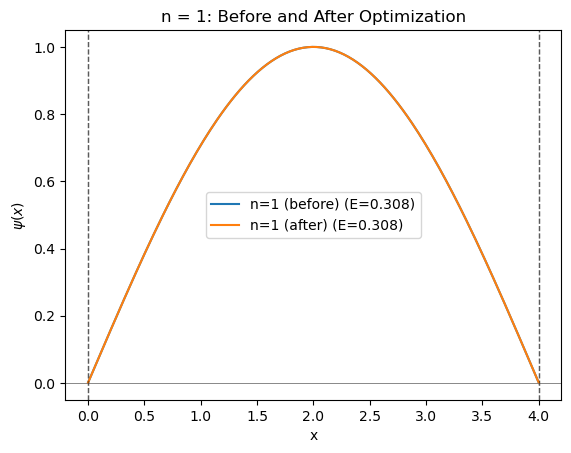

In [13]:
# n = 1 (worked example)
L = 4.0                             # YOUR COMMENT HERE
x = np.linspace(0, L, 200)          # YOUR COMMENT HERE

psi_1 = np.sin(1 * np.pi * x / L)   # YOUR COMMENT HERE 

# we can split up the arguments of a function into multiple lines for readability
result_1 = minimize(                # YOUR COMMENT HERE
    compute_energy,                 
    psi_1,                            
    args=(x,),                       
    method='CG'
    )

plot_wavefunction(x, psi_1, label='n=1 (before)') # YOUR COMMENT HERE
plot_wavefunction(x, result_1.x, label='n=1 (after)')
plt.title('n = 1: Before and After Optimization')
plt.show()

In [ ]:
# YOUR CODE HERE — repeat for n = 2


In [ ]:
# YOUR CODE HERE — repeat for n = 3


#### Part B — Varying the box length

Now fix $n = 1$ (the ground state) and repeat the same process for several different box lengths. Construct $\psi_1(x) = \sin(\pi x / L)$ for each $L$, optimize, and confirm that each one is unchanged.

In [ ]:
# YOUR CODE HERE - repeat for L = 4.0, n = 1
# HINT: you can use the code from the n=1 worked example here!

# add this line to your plotting instructions before you call plt.plot()
plt.xlim(0,12) # makes sure axis limits are the same for all plots so we can compare them

In [ ]:
# YOUR CODE HERE - repeat for L = 8.0, n = 1

In [ ]:
# YOUR CODE HERE - repeat for L = 12.0, n = 1

#### Part C — Discovering the energy formula

You've seen how $E$ depends on $n$ and $L$ individually. Now we're going to try to find the function that maps n and L to the energy E.

We'll generate data points using a `for` loop and then use `scipy.optimize.curve_fit` to optimize a function to fit it, like we did in the warmup.  

**Your task:** 

The model function `energy_model` does not fit the data. Modify it until the surface matches the data points.
**Add comments to the provided code explaining what each section does.**

In [ ]:
# --- Provided: compute energies for all (n, L) combinations ---
n_values = [1, 2, 3, 4, 5, 6]           # YOUR COMMENT HERE
L_values = [4, 6, 8, 10, 12]

n_list, L_list, E_list = [], [], []     # YOUR COMMENT HERE

for n in n_values:                      # YOUR COMMENT HERE
    for L in L_values:
        x = np.linspace(0, L, 500)      # YOUR COMMENT HERE
        psi = np.sin(n * np.pi * x / L) # YOUR COMMENT HERE
        E = compute_energy(psi, x)      # YOUR COMMENT HERE
        n_list.append(n)                # YOUR COMMENT HERE
        L_list.append(L)
        E_list.append(E)

n_arr = np.array(n_list)                # YOUR COMMENT HERE
L_arr = np.array(L_list)
E_arr = np.array(E_list)

In [ ]:
# Modify this function until the model surface matches the data points!
# curve_fit will optimize a, b, c for you — you just need the right functional form.
# If curve_fit fails, try adjusting p0 (the initial guess for the parameters).
def energy_model(nL, a, b, c):
    n, L = nL
    return a * n**b * L**c  # <-- this form doesn't work! fix it

from scipy.optimize import curve_fit
popt, pcov = curve_fit(energy_model, (n_arr, L_arr), E_arr, p0=[1.0, 1.0, 1.0])
a_fit, b_fit, c_fit = popt
print(f"Fitted parameters: a = {a_fit:.4f}, b = {b_fit:.4f}, c = {c_fit:.4f}")

In [ ]:
# --- Provided: plot data points and model surface ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Numerical data as scatter points
ax.scatter(L_arr, n_arr, E_arr, c='red', s=50, label='Numerical data')

# Model surface
n_grid, L_grid = np.meshgrid(np.linspace(1, 6, 30), np.linspace(4, 12, 30))
E_model = energy_model((n_grid, L_grid), *popt)
ax.plot_surface(L_grid, n_grid, E_model, alpha=0.3, cmap='viridis')

ax.set_xlabel('Box length L (a.u.)')
ax.set_ylabel('Quantum number n')
ax.set_zlabel('Energy (a.u.)')
ax.set_title('PIB Energy: Data vs. Model')
ax.legend()
plt.tight_layout()
plt.show()

### Question 2
`10 points`

- C4.2: Explain features of particle-in-a-box wavefunctions and their energies.

a) How does the shape of the wavefunction change as we increase n? As we increase L?

b) How does the energy of the wavefunction depend on the number of nodes? 

c) State the expression which best fit your data. Does it physically make sense in light of your answers to (a) and (b)? Explain your reasoning. 

---

*Your answer here (`double click me!`):*

---

<a id="part3"></a>

## Part 3 — Computational Chemistry

So far we have worked with the particle-in-a-box as a simplified model. Now we use quantum chemistry software to compute the electronic structure of **real molecules** and see how the model holds up.

We use the **Hartree–Fock (Self-Consistent Field, SCF)** method, which handles many interacting electrons by assuming each electron moves in the average field created by all the others. The procedure is:

1. **Initial guess** — build approximate orbitals from a set of basis functions (the **basis set**).
2. **Build the Fock operator** — an effective one-electron Hamiltonian including kinetic energy, nuclear attraction, and mean-field electron repulsion:
$$\hat{F}\psi_i = \varepsilon_i \psi_i$$
3. **Solve for new orbitals** — find orbital shapes and energies.
4. **Iterate** — repeat until the orbitals stop changing (**convergence**).

This is the same strategy as Part 1: start from a guess, minimize the energy, and let the physics determine the answer.

### HOMO–LUMO Gap

Each orbital holds two electrons (spin-up and spin-down). The highest filled orbital is the **HOMO** and the lowest empty orbital is the **LUMO**. Their energy difference

$$\Delta E = E_{\text{LUMO}} - E_{\text{HOMO}}$$

determines the energy of light the molecule can absorb. In Part 4 we will compare these gaps to the particle-in-a-box prediction.

---

### Coding Activity 3
`30 points`

- C4.3: Apply the particle-in-a-box model to conjugated polyenes.
- P4.3: Perform quantum chemical calculations with `psi4`.

#### Part A — Running a Hartree–Fock calculation

The cell below runs an HF/STO-3G calculation on **ethane** and plots its orbital energies. Run it and **add a comment to every line** explaining what it does.

Then, in the next cell, run the same calculation on **octatetraene** (`C=CC=CC=CC=C`) and plot its orbital energies.

In [ ]:
# --- Worked example: ethane ---
psi4.set_output_file('output.dat', False)
psi4.set_memory('1 GB')

mol_ethane = create_psi4_molecule('CC')
energy_ethane, wfn_ethane = psi4.energy('SCF/STO-3G', return_wfn=True, molecule=mol_ethane)
print(f'Ethane HF/STO-3G energy: {energy_ethane:.6f} a.u.')

# Plot all orbital energies
eps_ethane = wfn_ethane.epsilon_a().np
plt.plot(eps_ethane, 'o', markersize=5, color='steelblue')
plt.axhline(0, color='grey', linewidth=0.5)
plt.xlabel('Orbital index')
plt.ylabel('Energy (a.u.)')
plt.title('Ethane: All HF/STO-3G Orbital Energies')
plt.show()

In [ ]:
# YOUR CODE HERE
# Run HF/STO-3G on octatetraene (C=CC=CC=CC=C)
# Store the wavefunction in wfn_oct — you will need it in Parts B and C
# Plot all orbital energies


#### Part B — Visualizing molecular orbitals

The cell below generates cube files for orbitals near the HOMO and LUMO of octatetraene and displays them with `fortecubeview`. Run it, then examine the orbital shapes.

Octatetraene (C$_8$H$_{10}$) has $N_e = 58$ electrons, so the HOMO is orbital index 28 (zero-indexed).

**Your task:** identify which of the displayed orbitals are **$\pi$ orbitals** — they have lobes above and below the molecular plane. Record their indices; you will use them in Part C.

In [ ]:
# --- Given: orbital visualization ---
import os
os.makedirs('cubes', exist_ok=True)

# psi4 CUBEPROP_ORBITALS uses 1-indexed orbital numbers
homo_psi4 = 29  # octatetraene HOMO (1-indexed; 58 electrons / 2 = 29)
orb_numbers = list(range(homo_psi4 - 4, homo_psi4 + 5))  # [26, 27, 28, 29, 30, 31, 32]

psi4.set_options({
    'CUBEPROP_TASKS': ['orbitals'],
    'CUBEPROP_FILEPATH': 'cubes',
    'CUBEPROP_ORBITALS': orb_numbers,
})
psi4.cubeprop(wfn_oct)
fortecubeview.plot('cubes', colorscheme='wow')

In [ ]:
# Run this cell when you are done inspecting orbitals
shutil.rmtree('cubes', ignore_errors=True)

In [ ]:
# Record the orbital indices that you identified as pi orbitals:
pi_indices = []  # YOUR CODE HERE — e.g. [25, 26, 27, 28, 29, 30, 31]

#### Part C — Fitting the PIB model to $\pi$ orbital energies

Plot only the $\pi$ orbital energies, then try to fit the particle-in-a-box model $E = A \cdot n^2$ to them using `curve_fit`. Does the PIB model capture the pattern?

In [ ]:
# YOUR CODE HERE
# 1. eps = wfn_oct.epsilon_a().np
# 2. pi_energies = eps[pi_indices] * 27.211  (convert to eV)
# 3. n_pi = np.arange(1, len(pi_energies) + 1)
# 4. Plot pi_energies vs n_pi
# 5. Define: def pib_model(n, A): return A * n**2
# 6. Fit with curve_fit and plot the fit on top of the data

### Question 3
`15 points`

- C4.2: Explain features of particle-in-a-box wavefunctions and their energies.
- C4.4: Evaluate the tradeoffs of different physical models.

a) Look at the $\pi$ orbitals of octatetraene (which you visualized in part B). In what ways do they resemble the particle-in-a-box wavefunctions from Part 2?

b) How well does the PIB model $E = An^2 - b$ fit the $\pi$ orbital energies? What might account for any discrepancies?

c) Compare the Hartree–Fock procedure to the variational minimization you did in Part 1. What is conceptually the same? What is different?

---

*Your answer here (`double click me!`):*

---

<a id="part4"></a>

## Part 4 — Comparing Models

We now have two models for the electronic structure of conjugated polyenes:
- The **particle-in-a-box (PIB)** — a simple analytic formula with no adjustable parameters.
- **Hartree–Fock (HF)** — a detailed quantum-chemical calculation.

How do they compare to each other, and to **experiment**? And can we improve a simple model by fitting it to match experimental data?

This is a common strategy in computational chemistry: use a cheap model with empirically fitted parameters to approximate expensive calculations or experiments. If the cheap model captures the right *shape* of the relationship, a linear correction can bring the absolute values into agreement:

$$E_{\text{corrected}} = \alpha \cdot E_{\text{model}} + \beta$$

### Polyenes for this study

| $n_c$ | Name | XYZ file |
|-------|------|----------|
| 4 | butadiene | `data/butadiene.xyz` |
| 6 | hexatriene | `data/hexatriene.xyz` |
| 8 | octatetraene | `data/octatetraene.xyz` |
| 10 | decapentaene | `data/decapentaene.xyz` |
| 12 | dodecahexaene | `data/dodecahexaene.xyz` |
| 14 | tetradecaheptaene | `data/tetradecaheptaene.xyz` |
| 16 | hexadecaoctaene | `data/hexadecaoctaene.xyz` |

### Key formulas

- Total electrons: $n_e = 7 n_c + 2$
- HOMO index (zero-indexed): $n_e / 2 - 1$
- Conversion: 1 Hartree = 27.211 eV

---

### Coding Activity 4
`20 points`

- C4.3: Apply the particle-in-a-box model to conjugated polyenes.
- C4.4: Evaluate the tradeoffs of different physical models.
- P4.2: Fit nonlinear curves to data.

#### Part A — HF HOMO–LUMO Gaps

The cell below runs a Hartree–Fock calculation on **ethane** and extracts the HOMO–LUMO gap. Study it carefully — you will adapt this approach for the polyenes.

Ethane (C$_2$H$_6$) has $n_e = 18$ electrons, so the HOMO is at orbital index 8 (zero-indexed: $18/2 - 1 = 8$). The molecular geometry is loaded from a pre-built XYZ file using `load_psi4_molecule()`.

In [3]:
# --- Worked example: ethane HOMO-LUMO gap ---
mol_ethane = load_psi4_molecule('data/ethane.xyz')
energy_ethane, wfn_ethane = psi4.energy('SCF/STO-3G', return_wfn=True, molecule=mol_ethane)

eps_ethane = wfn_ethane.epsilon_a().np
n_e_ethane = 18
homo_idx = n_e_ethane // 2 - 1
lumo_idx = homo_idx + 1
gap_ethane = (eps_ethane[lumo_idx] - eps_ethane[homo_idx]) * 27.211  # convert to eV

print(f'Ethane HF/STO-3G energy: {energy_ethane:.6f} a.u.')
print(f'HOMO index: {homo_idx}, LUMO index: {lumo_idx}')
print(f'HOMO-LUMO gap: {gap_ethane:.2f} eV')


Scratch directory: /tmp/
   => Libint2 <=

    Primary   basis highest AM E, G, H:  6, 6, 3
    Auxiliary basis highest AM E, G, H:  7, 7, 4
    Onebody   basis highest AM E, G, H:  -, -, -
    Solid Harmonics ordering:            Gaussian

*** tstart() called on LaunchCodes
*** at Sun Feb 22 23:13:33 2026

   => Loading Basis Set <=

    Name: STO-3G
    Role: ORBITAL
    Keyword: BASIS
    atoms 1-2 entry C          line    61 file /home/zedo_heptulose/psi4conda/envs/chm4411l/share/psi4/basis/sto-3g.gbs 
    atoms 3-8 entry H          line    19 file /home/zedo_heptulose/psi4conda/envs/chm4411l/share/psi4/basis/sto-3g.gbs 


         ---------------------------------------------------------
                                   SCF
               by Justin Turney, Rob Parrish, Andy Simmonett
                          and Daniel G. A. Smith
                              RHF Reference
                        1 Threads,    500 MiB Core
         --------------------------------------------

ValidationError: Attempted to call .np on a Psi4 data object with multiple irreps.Please use .nph for objects with irreps.

In [4]:
# Subgoal: Compute HF HOMO-LUMO gaps for the polyenes

polyene_nc = [4, 6, 8, 10, 12, 14, 16]
polyene_xyz = [
    'data/butadiene.xyz',
    'data/hexatriene.xyz',
    'data/octatetraene.xyz',
    'data/decapentaene.xyz',
    'data/dodecahexaene.xyz',
    'data/tetradecaheptaene.xyz',
    'data/hexadecaoctaene.xyz',
]

hf_gaps = []

# YOUR CODE HERE
# Loop over polyene_nc and polyene_xyz
# For each molecule:
#   1. Load the psi4 molecule with load_psi4_molecule(xyz_file)
#   2. Run psi4.energy('SCF/STO-3G', ...)
#   3. Get orbital energies with wfn.epsilon_a().np
#   4. Compute n_e = 7 * n_c + 2, homo_idx = n_e // 2 - 1
#   5. Compute gap in eV and append to hf_gaps

print('HF HOMO-LUMO gaps (eV):', hf_gaps)

HF HOMO-LUMO gaps (eV): []


In [ ]:
# Subgoal: Plot HF gaps vs chain length

# YOUR CODE HERE


#### Part B — PIB HOMO–LUMO Gaps

The particle-in-a-box model gives the energy of level $n$ as:

$$E_n = \frac{n^2 \pi^2}{2 L^2} \quad \text{(atomic units)}$$

For a polyene with $n_c$ carbon atoms:
- Box length: $L = 1.4 \times (n_c - 1)$ Å, converted to a.u. by multiplying by 1.8897
- HOMO quantum number: $n_{\text{HOMO}} = n_c / 2$
- LUMO quantum number: $n_{\text{LUMO}} = n_c / 2 + 1$
- Gap: $\Delta E = E_{\text{LUMO}} - E_{\text{HOMO}}$, converted to eV by multiplying by 27.211

In [ ]:
# Subgoal: Write a function that returns the PIB HOMO-LUMO gap in eV

def pib_energy_gap(n_c):
    """
    Compute the PIB HOMO-LUMO gap for a polyene with n_c carbons.
    
    Parameters
    ----------
    n_c : int
        Number of carbon atoms.
    
    Returns
    -------
    gap_eV : float
        HOMO-LUMO gap in eV.
    """
    # YOUR CODE HERE
    # 1. Compute L in Angstroms: L = 1.4 * (n_c - 1)
    # 2. Convert to atomic units: L_au = L * 1.8897
    # 3. n_homo = n_c // 2, n_lumo = n_c // 2 + 1
    # 4. E_n = n^2 * pi^2 / (2 * L_au^2)
    # 5. gap = (E_lumo - E_homo) * 27.211


In [ ]:
# Subgoal: Compute PIB gaps and plot alongside HF gaps

pib_gaps = []

# YOUR CODE HERE
# 1. Loop over polyene_nc and compute pib_energy_gap for each
# 2. Plot both hf_gaps and pib_gaps vs polyene_nc on the same axes
#    with labels, legend, axis labels, and title


#### Part C — Comparison to Experiment

We have experimental UV absorption data for these polyenes. Let's see how both models compare to reality.

We'll also apply a **linear correction** to each model:

$$E_{\text{corrected}} = \alpha \cdot E_{\text{model}} + \beta$$

This fits two parameters ($\alpha$, $\beta$) to best match the experimental data. If the model captures the right *trend*, the correction should give good agreement.

In [ ]:
# --- Given: load experimental data ---
expt_data = pd.read_csv('data/polyene_excitation.csv')
print(expt_data)

expt_energies = expt_data['excitation_energy_eV'].values

In [ ]:
# Subgoal: Plot all three datasets (HF, PIB, experiment) on the same axes

# YOUR CODE HERE
# Plot hf_gaps, pib_gaps, and expt_energies vs polyene_nc
# Use different markers/colors and a legend


In [ ]:
# Subgoal: Fit linear corrections to both models

def linear_model(x, alpha, beta):
    """Linear correction: alpha * x + beta."""
    return alpha * x + beta

# YOUR CODE HERE
# 1. Use curve_fit to fit linear_model to (hf_gaps, expt_energies)
#    Store result as popt_hf
# 2. Use curve_fit to fit linear_model to (pib_gaps, expt_energies)
#    Store result as popt_pib
# 3. Print the fitted parameters for each model


In [ ]:
# Subgoal: Compare corrected predictions to experiment

# YOUR CODE HERE
# 1. Compute corrected predictions:
#    hf_corrected = linear_model(np.array(hf_gaps), *popt_hf)
#    pib_corrected = linear_model(np.array(pib_gaps), *popt_pib)
# 2. Plot expt_energies, hf_corrected, pib_corrected vs polyene_nc
# 3. Compute and print R^2 for each:
#    calculate_r_squared(expt_energies, hf_corrected)
#    calculate_r_squared(expt_energies, pib_corrected)


### Question 4
`10 points`

- C4.3: Apply the particle-in-a-box model to conjugated polyenes.
- C4.4: Evaluate the tradeoffs of different physical models.

a) How well do the SCF and PIB models fit the experimental data before and after the linear correction? Which is the more accurate method?

b) Look at the timings at the bottom of the notebook cells where you ran your calculations. How long did the SCF calculations take? How about the PIB calculations?

c) Evaluate the relative utility of the PIB and SCF models in terms of accuracy, computational cost, and conceptual clarity. Give an example of a scenario in which you would use each.

---

*Your answer here (`double click me!`):*

---

<a id="reflection"></a>

## Reflection
`10 points`

a) In this lab, you worked with models at several levels of detail: a simple analytic formula (PIB), a numerical variational procedure, and a full quantum-chemical method (Hartree–Fock). In your own words, what makes a model "useful" even when it is known to be imperfect?

b) Describe one situation in this lab where a numerical procedure (optimization, curve fitting, or iteration) was essential — where you could not have obtained the result by hand calculation alone. What did you learn from this?

c) What is one thing from this lab that you found surprising or that changed how you think about quantum mechanics or computational chemistry?

*Your answer here (`double click me!`):*